In [ ]:
import plotly.figure_factory as ff
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('creditcard.csv')
#credit_data

In [ ]:
data.shape

(284807, 31)

In [ ]:
data.describe()

In [ ]:
data.isnull().sum()

In [ ]:
data['Class'].value_counts(normalize=True)
# Fraud Vs Non-fraud percentage

In [ ]:
data = data.drop_duplicates()

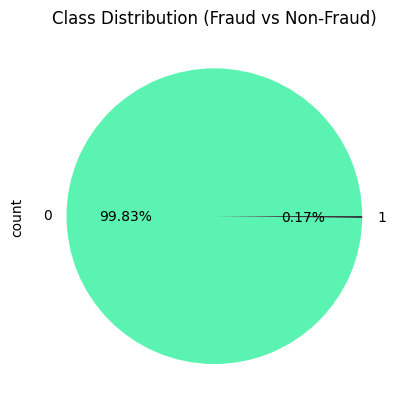

In [ ]:
# Graph
import seaborn as sns
import matplotlib.pyplot as plt
# colors = ['#0C1A2B', '#B6FF3B']
colors = ['#5AF3B1', '#0B0F14']
data['Class'].value_counts().plot.pie(autopct='%1.2f%%', colors = colors)
plt.title('Class Distribution (Fraud vs Non-Fraud)')
plt.show()


Time vs Features


In [ ]:
data["Time_hr"] = data['Time'].apply(lambda x:np.floor(x/3600))
# Aggregrate statistics by Time_hr and Class

time_cls_stat = data.groupby(['Time_hr','Class'])['Amount'].aggregate(
    ['min', 'max', 'mean', 'median', 'var']
).reset_index()

df = pd.DataFrame(time_cls_stat)
df.columns = ['Time_hr', 'Class', 'Min', 'Max', 'Mean', 'Median', 'Var']
df.head()

,Time_hr,Class,Min,Max,Mean,Median,Var
0,0.0,0,0.0,7712.43,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,68.803466,17.900,45355.430437


In [ ]:
# Time Vs Class visualisation
class_0 = df.loc[df['Class'] == 0]['Time_hr']
class_1 = df.loc[df['Class'] == 1]['Time_hr']

hist_data = [class_0, class_1]
group_labels = ['Non Fraud', 'Fraud']

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug= False)
fig['layout'].update(
    title='Time Density With Class Plot',
    xaxis=dict(title='Time'),
    yaxis=dict(title='Density')
)
iplot(fig)

/tmp/ipykernel_430/2003261660.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




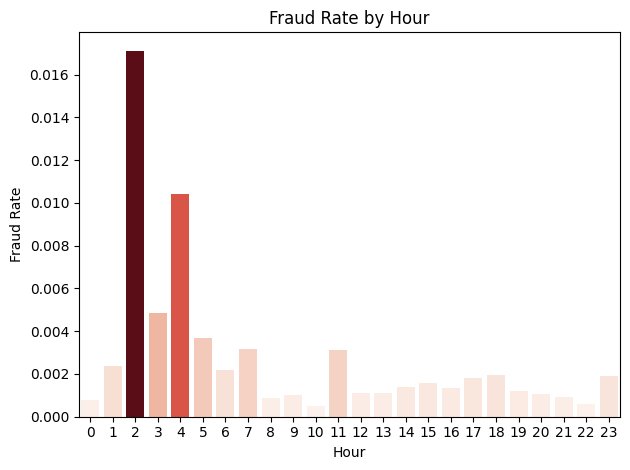

In [ ]:
#Fraud by Hour Plot
fraud_by_hour24 = ((data['Time'] // 3600) % 24).astype(int)
fraud_by_hour24
fraud_by_hour = data.groupby(fraud_by_hour24)["Class"].mean()

cmap = sns.color_palette("Reds", as_cmap=True)
vals = (fraud_by_hour / fraud_by_hour.max()).values
pal = [cmap(v) for v in vals]

sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, palette=pal)
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

In [ ]:
# Scatter Plot
# fraud = data.loc[data['Class'] == 1]
# non_fraud = data.loc[data['Class'] == 0]

# plt.figure(figsize=(12,8))
# plt.scatter(fraud['Time'], fraud['Amount'], c='red',alpha=0.5, )
# plt.scatter(non_fraud['Time'], non_fraud['Amount'], c='green',alpha=0.5, )

# plt.grid(True, alpha=0.6)
# plt.gca().set_facecolor('#f9f9f9')
# plt.title('Scatter Plot of Fraudulent Transactions')
# plt.xlabel('Time')
# plt.ylabel('Amount')
# plt.legend()
# plt.show()

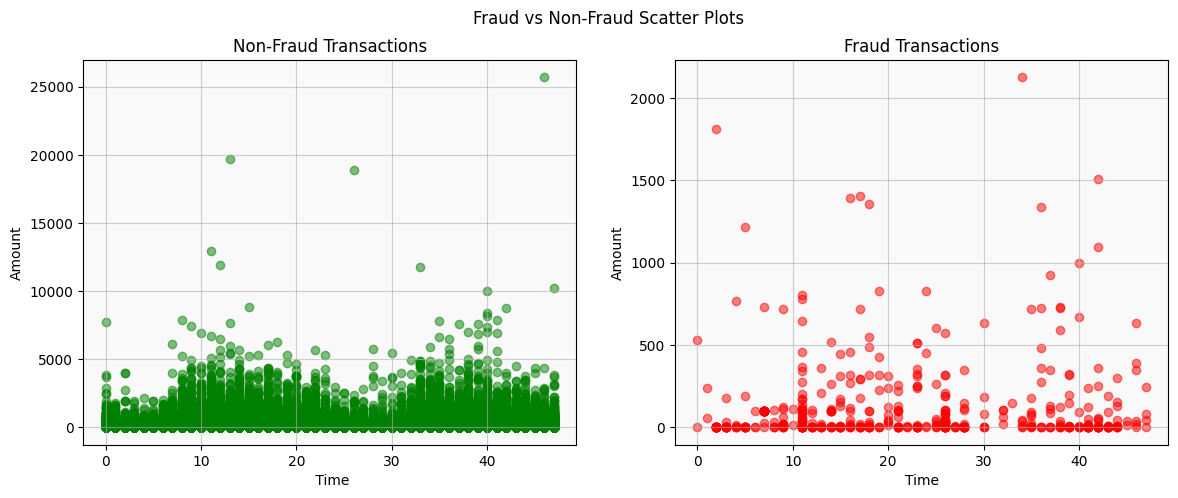

In [ ]:
fraud = data[data['Class'] == 1]
non_fraud = data[data['Class'] == 0]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns

# Non-Fraud scatter
axes[0].scatter(non_fraud['Time_hr'], non_fraud['Amount'],
                color='green', alpha=0.5)
axes[0].grid(True, alpha=0.6)
axes[0].set_facecolor('#f9f9f9')
axes[0].set_title('Non-Fraud Transactions')
axes[0].set_xlabel(' Time')
axes[0].set_ylabel('Amount')

# Fraud scatter
axes[1].scatter(fraud['Time_hr'], fraud['Amount'],
                color='red', alpha=0.5)
axes[1].grid(True, alpha=0.6)
axes[1].set_facecolor('#f9f9f9')
axes[1].set_title('Fraud Transactions')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amount')

plt.suptitle('Fraud vs Non-Fraud Scatter Plots')
plt.show()

CORRELATION


In [ ]:
corr_matrix = data.corr()
fraud_corr = corr_matrix['Class'].sort_values(ascending=False)
fraud_corr
print(fraud_corr)

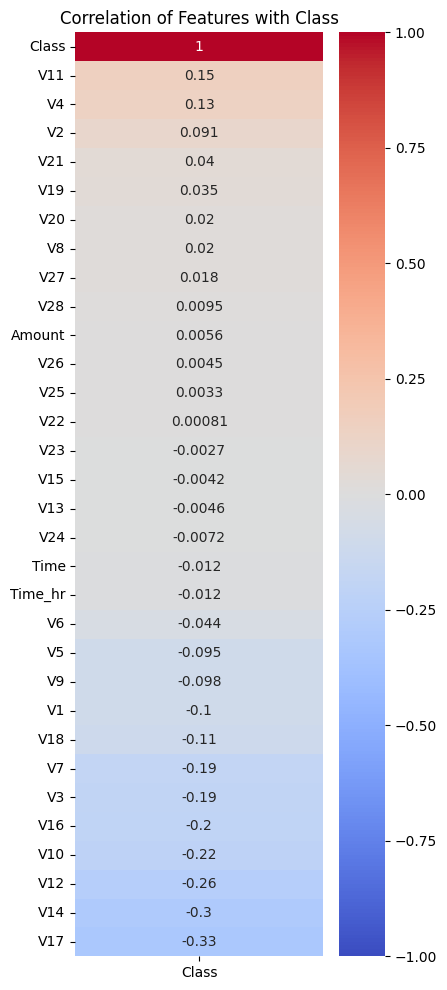

In [ ]:
fraud_corr = corr_matrix[['Class']].sort_values(by='Class', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(fraud_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Class')
plt.show()

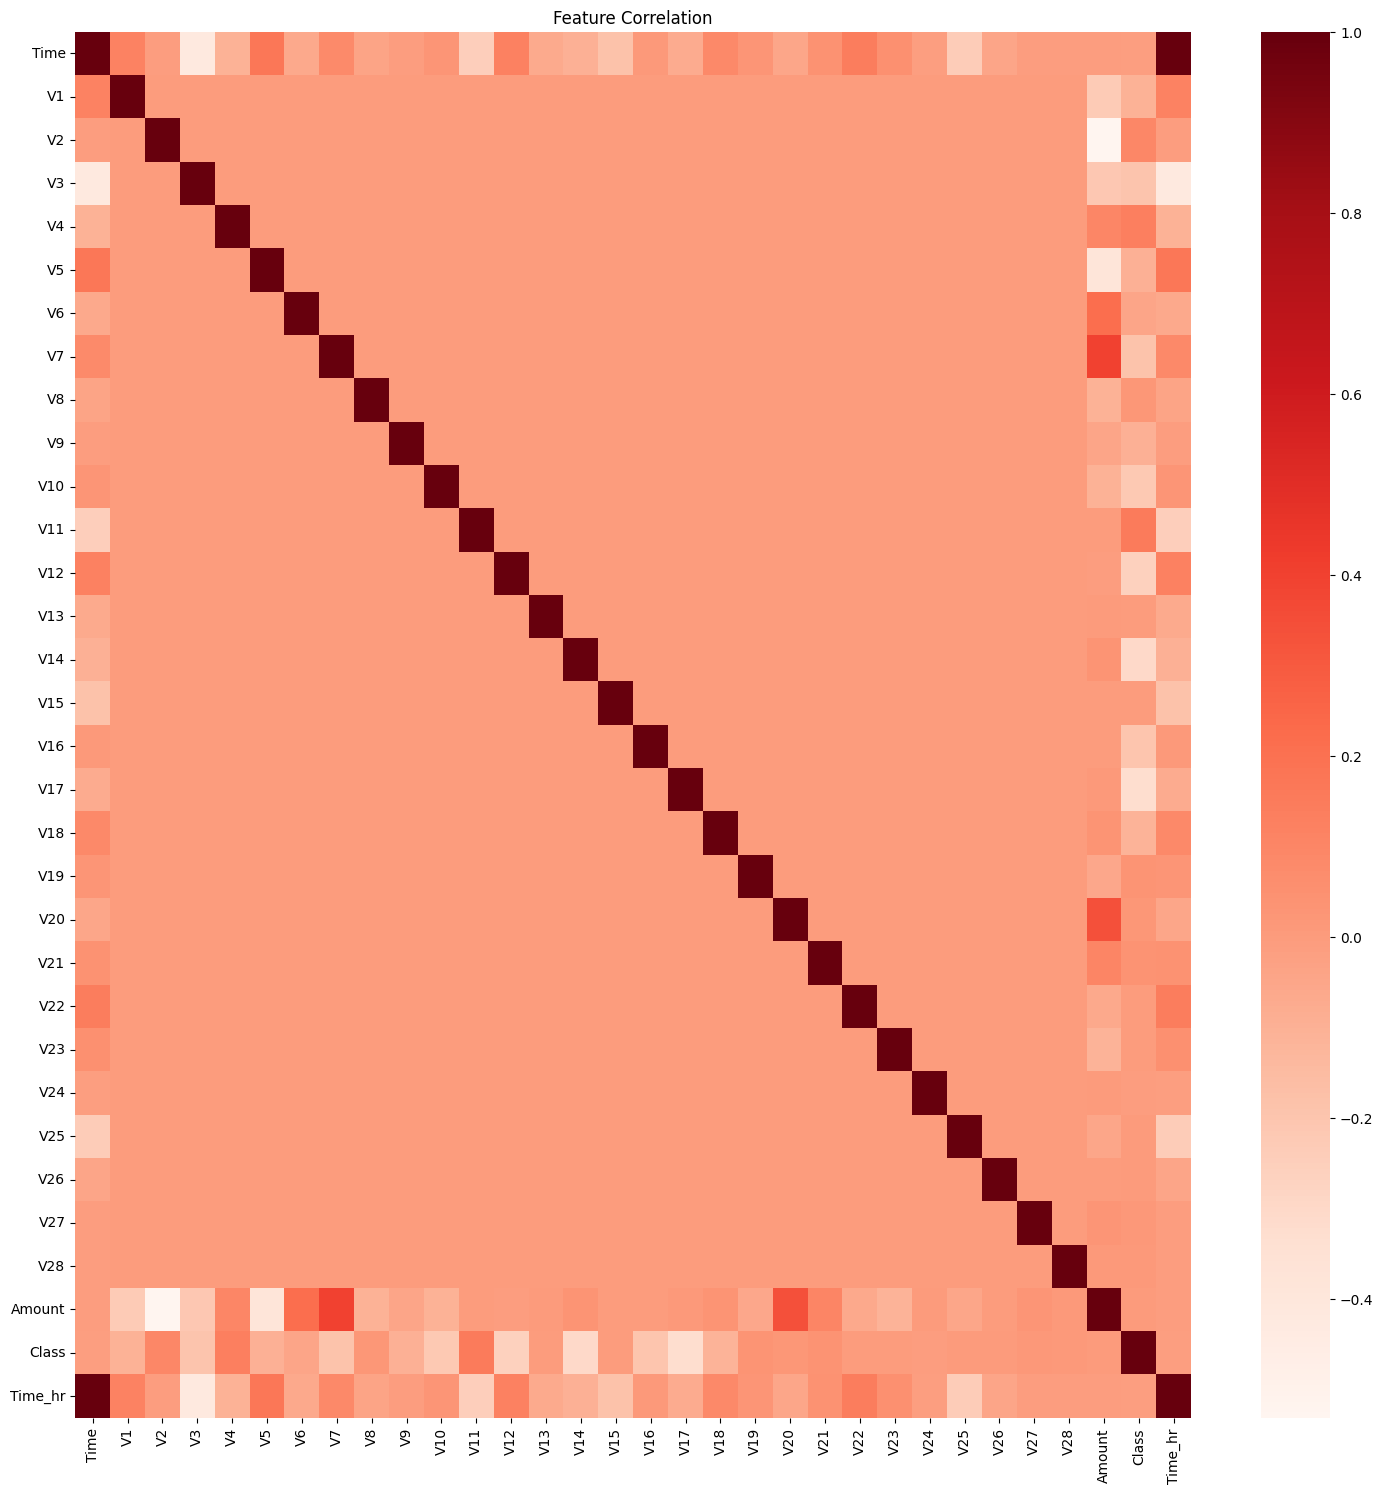

In [ ]:
plt.figure(figsize=(18,18))
corr= data.corr()
sns.heatmap(corr, cmap='Reds')
plt.title("Feature Correlation")
plt.show()

In [ ]:
#Multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = data.columns
vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)
vif_data

In [ ]:
# var = data.columns.values

# t0 = data.loc[data['Class'] == 0]
# t1 = data.loc[data['Class'] == 1]

# sns.set_style('whitegrid')
# fig, ax = plt.subplots(8,4,figsize=(16,28))

# for i, feature in enumerate(var, 1):
#     if t0[feature].nunique() <= 1 and t1[feature].nunique() <= 1:
#         continue  # skip constant columns
#     plt.subplot(8,4,i)
#     sns.kdeplot(t0[feature], bw_method=0.5, label="Class = 0", color="#5bc0be")
#     sns.kdeplot(t1[feature], bw_method=0.5, label="Class = 1", color="crimson")
#     plt.xlabel(feature, fontsize=12)
#     plt.tick_params(axis='both', which='major', labelsize=12)

# plt.suptitle("Feature Distributions by Class (KDE)", fontsize=20, color="#f8f8f8", backgroundcolor="#1f2833")
# plt.tight_layout()
# plt.show()

**MODEL**


In [ ]:

# Train Test Split
from sklearn.model_selection import train_test_split

X = data.drop(['Class', 'Time_hr'], axis=1)
y = data['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)
THRESHOLD = 0.3
print(f"X Train data shape: {X_train.shape}")
print(f"X Temp data shape: {X_temp.shape}")
print(f"y Train data shape: {y_train.shape}")
print(f"y Temp data shape: {y_temp.shape}")
# print(f"X Valid data shape: {X_val.shape}")
# print(f"X Test data shape: {X_test.shape}")


X Train data shape: (227845, 30)
X Temp data shape: (56962, 30)
y Train data shape: (227845,)
y Temp data shape: (56962,)


In [ ]:
#Smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(272941, 30)
(272941,)


Random Forest Classifier

In [ ]:
# from imblearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler

# pipeline = Pipeline([
#     ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
#     ('model', RandomForestClassifier(
#         n_estimators=NUM_ESTIMATORS,
#         random_state=RANDOM_STATE,
#         class_weight='balanced'
#     ))
# ])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

X_val_proba = rf.predict_proba(X_val)[:, 1]
y_val_pred = (X_val_proba >= THRESHOLD).astype(int)

print(classification_report(y_val, y_val_pred, digits=3))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_val)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (X_val_proba >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec = recall_score(y_val, preds, pos_label=1)
    f1 = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.647   0.880   0.746   
0.3     0.710   0.880   0.786   
0.35    0.759   0.880   0.815   
0.4     0.759   0.880   0.815   
0.45    0.759   0.880   0.815   
0.5     0.778   0.840   0.808   


**XGBoost**


In [ ]:
# @title
from xgboost import XGBClassifier
import time
scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

start_train = time.time()
xgb.fit(X_train_smote, y_train_smote)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
xgb_val_proba = xgb.predict_proba(X_val)[:, 1]
y_xgb_pred = (xgb_val_proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, y_xgb_pred, digits=3))

In [ ]:
# @title
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_val)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_val, preds, pos_label=1)
    rec = recall_score(y_val, preds, pos_label=1)
    f1 = f1_score(y_val, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

In [ ]:
# @title
#Standardising
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_smote)
# X_valid_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
#Evaluation on Test Set
y_test_pred = rf.predict(X_test)
y_test_prob = rf.predict_proba(X_test)[:,1]
y_test_pred.shape

(42721,)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, roc_auc_score, precision_score, f1_score
print("Confusion Matrix: ", confusion_matrix(y_test, y_test_pred))
print("Recall: ", recall_score(y_test, y_test_pred))
print("Roc Auc Score: ", roc_auc_score(y_test, y_test_prob))
print("Precision Score: ", precision_score(y_test, y_test_pred))
print("F1 Score: ", f1_score(y_test, y_test_pred))

Confusion Matrix:  [[42640     8]
 [   13    60]]
Recall:  0.821917808219178
Roc Auc Score:  0.9640651860531448
Precision Score:  0.8823529411764706
F1 Score:  0.851063829787234


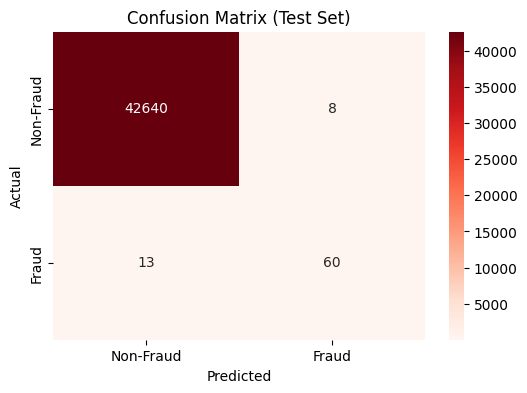

In [ ]:
#Confusion Matrix Visualisation

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

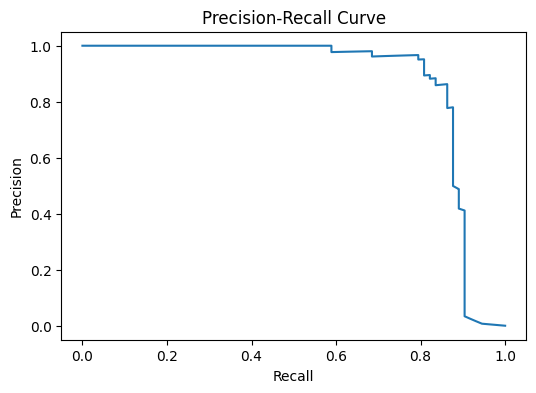

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

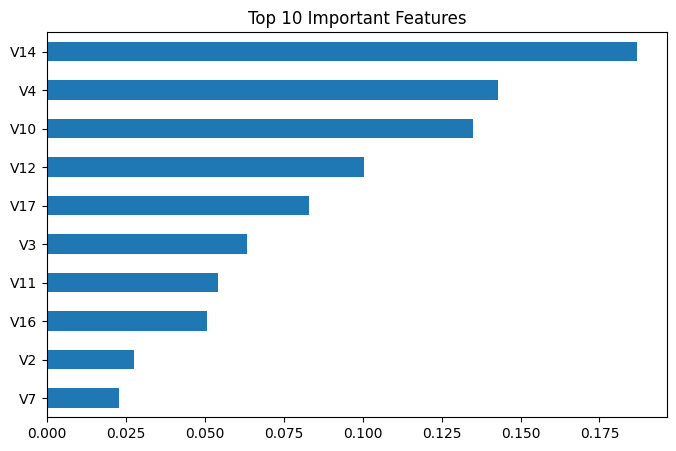

In [ ]:
#Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()